In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [2]:
# Load combined json file (created with collectData.py)
dfs = {}
for jsonFile in ['C1C1_effs.json','C1N1_effs.json']:
    with open(jsonFile, 'r') as f:
        data = json.load(f)

    columns = list(data[0].keys())
    columns.remove('Efficiencies')
    # Expand efficiencies for all lifetimes
    df = pd.json_normalize(
        data,
        record_path="Efficiencies",  # list to explode
        meta=columns
    )
    # Keep only the necessary information:
    # mLLP = LLP mass (GeV)
    # tau0_ns = lifetime used for event generation (ns)
    # tau_ns = lifetime used for reweights (ns)
    # EWK SR = efficiency for the EWK signal region
    # EWK SR Error = MC errior for the efficiency
    df['width_GeV'] = 6.582e-16/df['tau_ns']
    df = df[['mLLP','width_GeV','tau0_ns','tau_ns','EWK SR', 'EWK SR Error']]
    # Add width column    
    dfs[jsonFile] = df

### For each (mLLP,tau) keep only the entry with tau/tau0 closest to 1

In [3]:
for jsonFile,df in dfs.items():
    keep_indices = []
    for group,df_g in df.groupby(['mLLP','tau_ns']):
        imin = np.argmin(np.abs(1.0-df_g['tau_ns']/df_g['tau0_ns']))
        ii = df_g.index.to_list()[imin]
        keep_indices.append(ii)
    dfs[jsonFile] = df[df.index.isin(keep_indices)]

In [4]:
dfs['C1C1_effs.json']

,mLLP,width_GeV,tau0_ns,tau_ns,EWK SR,EWK SR Error
28,100.0,3.291000e-16,10.0,2.0,0.000594,0.000198
29,100.0,2.194000e-16,10.0,3.0,0.000438,0.000146
30,100.0,1.316400e-16,10.0,5.0,0.000285,0.000095
31,100.0,1.097000e-16,10.0,6.0,0.000243,0.000081
32,100.0,9.402857e-17,10.0,7.0,0.000211,0.000070
...,...,...,...,...,...,...
764,500.0,9.402857e-16,1.0,0.7,0.006893,0.000283
765,500.0,8.227500e-16,1.0,0.8,0.007040,0.000286
766,500.0,6.582000e-16,1.0,1.0,0.007079,0.000285
767,500.0,5.063077e-16,1.0,1.3,0.006827,0.000277


## Plot Efficiencies

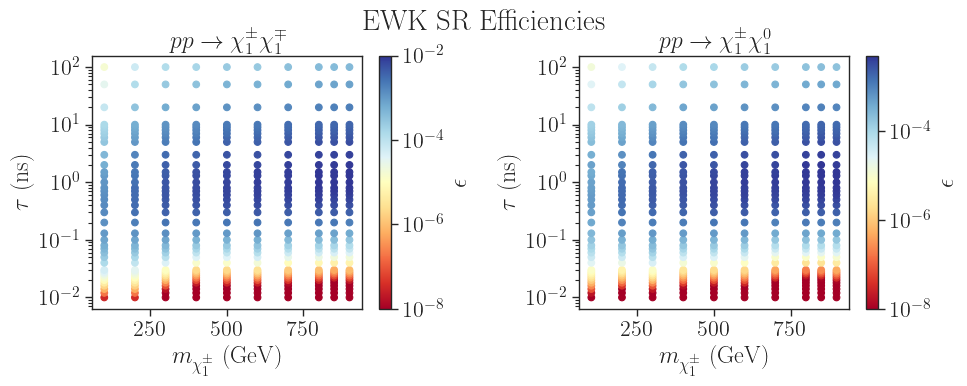

In [5]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

labelDict = {'C1C1_effs.json' : r'$p p \to \chi_1^\pm \chi_1^\mp$',
          'C1N1_effs.json' : r'$p p \to \chi_1^\pm \chi_1^0$'}

for ax,label in zip(axList,labelDict.keys()):
    df = dfs[label]
    x = df['mLLP']
    y = df['tau_ns']
    z = df['EWK SR']

    im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(labelDict[label])

plt.tight_layout()
plt.suptitle('EWK SR Efficiencies')
plt.show()

## Plot Efficiency Uncertainties

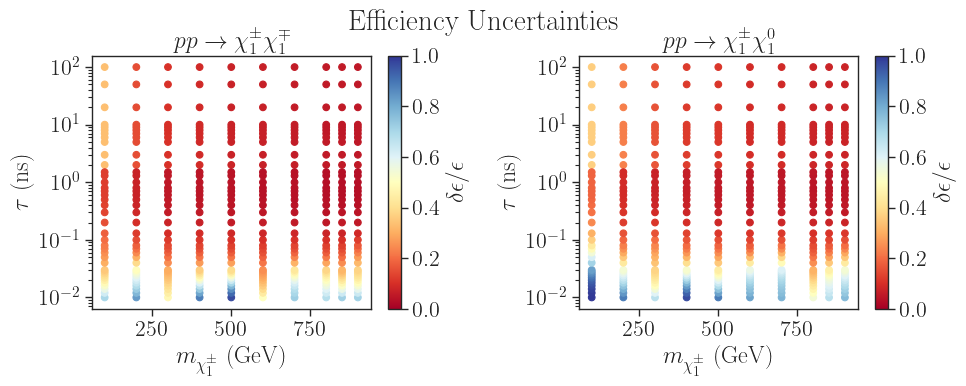

In [6]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

labelDict = {'C1C1_effs.json' : r'$p p \to \chi_1^\pm \chi_1^\mp$',
          'C1N1_effs.json' : r'$p p \to \chi_1^\pm \chi_1^0$'}

for ax,label in zip(axList,labelDict.keys()):
    df = dfs[label]
    x = df['mLLP']
    y = df['tau_ns']
    z = df['EWK SR Error']/df['EWK SR']

    im = ax.scatter(x,y,c=z,cmap=cm,
                    vmin=0.0,vmax=1.0,
                    # norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)),
                    )
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\delta \epsilon / \epsilon$')

    ax.set_title(labelDict[label])

plt.tight_layout()
plt.suptitle('Efficiency Uncertainties')
plt.savefig('wino_effs_uncertainties.png')
plt.show()